# EfficientLoFTR on EVA02 retrieval pairs

Identity-disjoint fold-0 OOF of LLM2CLIP EVA02-L-14-336 plus HDBSCAN mcs4 (`runs/cv/pseudo_iter001_mcs4`). The ranker is still the 256-D embedding. EfficientLoFTR (`weights/efficientloftr`) only looks at a query crop and a gallery crop and reports semi-dense correspondences.

Questions:

1. On a true positive vs a Rank-1 distractor, do the matches land on the vehicle and how many survive homography RANSAC?
2. If we re-sort only the cosine top-10 by `n_inliers` / `n_matches` / `score_sum`, or by a min-max hybrid with cosine, does Rank-1 / mAP move?

Protocol matches eval: drop same-camera same-identity gallery images, keep other cameras. Matching is not applied to the full gallery.


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "train.csv").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from omegaconf import OmegaConf
from PIL import Image

from dataset.images import crop_bbox, image_path
from matching import (
    draw_matches,
    hybrid_head,
    load_matcher,
    match_pair,
    match_pairs,
    match_stats,
    ranking_row,
    reorder_head,
    summarize,
)
from postproc.retrieval import normalize

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


def display(obj):
    print(obj if isinstance(obj, str) else obj.to_string() if hasattr(obj, "to_string") else obj)


def pick_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    for index in range(torch.cuda.device_count()):
        free, total = torch.cuda.mem_get_info(index)
        if free / max(total, 1) > 0.95:
            return torch.device(f"cuda:{index}")
    return torch.device("cpu")


CV = ROOT / "runs" / "cv" / "pseudo_iter001_mcs4"
IMAGES = ROOT / "data" / "images"
FOLD = 0
VAL = CV / f"fold{FOLD}" / "val"
FIG_DIR = ROOT / "notebooks" / "eva02" / "matching_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = pick_device()
CONTEXT = float(OmegaConf.load(VAL / "config.yaml").data.context_pct)
processor, matcher = load_matcher(ROOT / "weights" / "efficientloftr", device=DEVICE)
print("ROOT", ROOT)
print("device", DEVICE)
print("context_pct", CONTEXT)

/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ROOT /data/projects/ryzhichkin/ReID
device cuda:0
context_pct 6.201741080661072


In [3]:
oof = pd.read_csv(VAL / "oof.csv", dtype={"image_id": str})
query = pd.read_csv(VAL / "query.csv", dtype={"image_id": str})
gallery = pd.read_csv(VAL / "gallery.csv", dtype={"image_id": str})
emb = normalize(np.load(VAL / "embeddings.npy"))
lookup = {image_id: i for i, image_id in enumerate(oof.image_id)}
qe = emb[[lookup[i] for i in query.image_id]]
ge = emb[[lookup[i] for i in gallery.image_id]]
qids = query.vehicle_id.to_numpy()
gids = gallery.vehicle_id.to_numpy()
qcams = query.camera_id.to_numpy()
gcams = gallery.camera_id.to_numpy()
orders = []
rows = []
for i in range(len(query)):
    keep = ~((gcams == qcams[i]) & (gids == qids[i]))
    order = np.argsort(-(qe[i] @ ge.T), kind="stable")
    order = order[keep[order]]
    orders.append(order)
    rec = ranking_row(order, qids[i], gids)
    rec.update(
        {
            "q_index": i,
            "image_id": query.image_id.iloc[i],
            "vehicle_id": int(qids[i]),
            "r1_id": gallery.image_id.iloc[order[0]],
            "pos_id": gallery.image_id.iloc[order[np.flatnonzero(gids[order] == qids[i])[0]]],
        }
    )
    rows.append(rec)
qtab = pd.DataFrame(rows)
easy = qtab.sort_values("ap", ascending=False).head(2)
miss = qtab[~qtab.rank1].head(2)
print(qtab[["ap", "rank1", "pos_rank"]].describe())
display(pd.concat([easy, miss])[["image_id", "vehicle_id", "ap", "rank1", "pos_rank"]])

               ap    pos_rank
count  309.000000  309.000000
mean     0.840484    1.987055
std      0.273356    3.941104
min      0.035874    1.000000
25%      0.750000    1.000000
50%      1.000000    1.000000
75%      1.000000    1.000000
max      1.000000   44.000000
                             image_id  vehicle_id        ap  rank1  pos_rank
308  f8100578c7344b06acd040ae4ea6543a        1283  1.000000   True         1
0    34ce7989a4c440a882c40fa7891ce9d4          63  1.000000   True         1
6    974014bd0d8f449dbdffecf8fa039ea0         513  0.142857  False         7
30   019df33848224006bf565042c625c773          58  0.133025  False         4


In [4]:
def frame_row(image_id):
    hit = oof.loc[oof.image_id == image_id]
    if len(hit) == 0:
        hit = pd.concat([query, gallery], ignore_index=True)
        hit = hit.loc[hit.image_id == image_id]
    return hit.iloc[0]


def load_crop_array(image_id):
    row = frame_row(image_id)
    with Image.open(image_path(IMAGES, image_id)) as im:
        crop = crop_bbox(im.convert("RGB"), [row.x, row.y, row.w, row.h], CONTEXT)
    return np.asarray(crop.convert("RGB"))


def pair_view(query_id, gallery_id, threshold=0.2):
    q_rgb = load_crop_array(query_id)
    g_rgb = load_crop_array(gallery_id)
    pair = match_pair(processor, matcher, q_rgb, g_rgb, threshold=threshold)
    stats = match_stats(pair["keypoints0"], pair["keypoints1"], pair["scores"])
    canvas = draw_matches(q_rgb, g_rgb, pair["keypoints0"], pair["keypoints1"], pair["scores"])
    return canvas, stats

## Matches on easy hits and Rank-1 misses

Green lines are high-score correspondences. `n_inliers` is how many of those points fit one homography. A true pair should light up body panels that exist in both views; a distractor often matches color blobs that are not geometrically consistent.


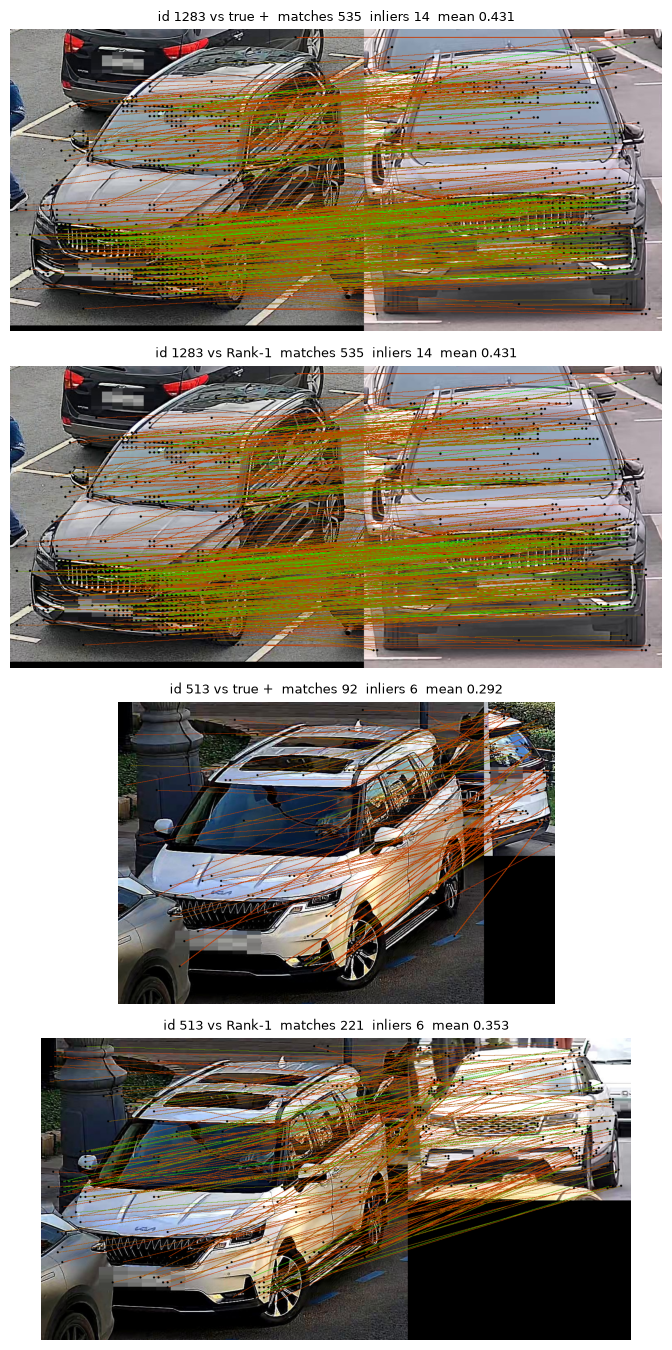

               title  n_matches  n_inliers  inlier_ratio   score_sum  score_mean  score_max
0  id 1283 vs true +        535         14      0.026168  230.442307    0.430733   0.974556
1  id 1283 vs Rank-1        535         14      0.026168  230.442307    0.430733   0.974556
2   id 513 vs true +         92          6      0.065217   26.857254    0.291927   0.647281
3   id 513 vs Rank-1        221          6      0.027149   78.058151    0.353204   0.890816


In [5]:
views = []
for rec in pd.concat([easy.head(1), miss.head(1)]).to_dict("records"):
    views.append((f"id {rec['vehicle_id']} vs true +", rec["image_id"], rec["pos_id"]))
    views.append((f"id {rec['vehicle_id']} vs Rank-1", rec["image_id"], rec["r1_id"]))
fig, axes = plt.subplots(len(views), 1, figsize=(12, 3.4 * len(views)))
vis_rows = []
for ax, (title, qid, gid) in zip(axes, views, strict=True):
    canvas, stats = pair_view(qid, gid)
    ax.imshow(canvas)
    ax.set_title(
        f"{title}  matches {stats['n_matches']}  inliers {stats['n_inliers']}"
        f"  mean {stats['score_mean']:.3f}",
        fontsize=9,
    )
    ax.axis("off")
    vis_rows.append({"title": title, **{k: stats[k] for k in stats if k != "inliers"}})
plt.tight_layout()
fig.savefig(FIG_DIR / "pairs.png", dpi=120, bbox_inches="tight")
plt.show()
display(pd.DataFrame(vis_rows))

Saved figure (also written to `notebooks/eva02/matching_figs/pairs.png`):

![pairs](matching_figs/pairs.png)


## Top-10 verifier

For every OOF query, match the cosine top-10 gallery crops. Re-sort that head by match evidence; the tail stays in cosine order. Hybrid min-max mixes cosine and `n_inliers` inside the head (`weight=0.5`).


In [6]:
TOPK = 10
BATCH = 8
THRESH = 0.2
cache = {}


def cached_crop(image_id):
    if image_id not in cache:
        cache[image_id] = load_crop_array(image_id)
    return cache[image_id]


flat_pairs = []
flat_meta = []
for qi, order in enumerate(orders):
    q_rgb = cached_crop(query.image_id.iloc[qi])
    for gi in order[:TOPK]:
        flat_pairs.append((q_rgb, cached_crop(gallery.image_id.iloc[int(gi)])))
        flat_meta.append((qi, int(gi)))
matched = []
for start in range(0, len(flat_pairs), BATCH):
    chunk = flat_pairs[start : start + BATCH]
    matched.extend(match_pairs(processor, matcher, chunk, threshold=THRESH, batch_size=BATCH))
    if start % (BATCH * 20) == 0:
        print(f"matched {min(start + BATCH, len(flat_pairs))} / {len(flat_pairs)}")
print("pairs", len(matched))

matched 8 / 3090


matched 168 / 3090


matched 328 / 3090


matched 488 / 3090


matched 648 / 3090


...

matched 2568 / 3090


matched 2728 / 3090


matched 2888 / 3090


matched 3048 / 3090


pairs 3090


In [7]:
stats = [match_stats(m["keypoints0"], m["keypoints1"], m["scores"]) for m in matched]
n_g = len(gallery)
by_query = [{} for _ in orders]
for (qi, gi), st in zip(flat_meta, stats, strict=True):
    by_query[qi][gi] = st
protocols = ("cosine", "n_inliers", "n_matches", "score_sum", "hybrid")
rows_by = {name: [] for name in protocols}
scatter = []
for qi, order in enumerate(orders):
    cosine = qe[qi] @ ge.T
    filled = {kind: np.zeros(n_g, dtype=np.float64) for kind in ("n_inliers", "n_matches", "score_sum")}
    for gi, st in by_query[qi].items():
        filled["n_inliers"][gi] = st["n_inliers"]
        filled["n_matches"][gi] = st["n_matches"]
        filled["score_sum"][gi] = st["score_sum"]
        scatter.append(
            {
                "cosine": float(cosine[gi]),
                "n_inliers": st["n_inliers"],
                "n_matches": st["n_matches"],
                "same_id": bool(gids[gi] == qids[qi]),
                "is_r1": bool(gi == order[0]),
            }
        )
    qid = qids[qi]
    rows_by["cosine"].append(ranking_row(order, qid, gids))
    for kind in ("n_inliers", "n_matches", "score_sum"):
        rows_by[kind].append(ranking_row(reorder_head(order, filled[kind], TOPK), qid, gids))
    mixed = np.zeros(n_g, dtype=np.float64)
    mixed[order[:TOPK]] = hybrid_head(order, cosine, filled["n_inliers"], TOPK, weight=0.5)
    rows_by["hybrid"].append(ranking_row(reorder_head(order, mixed, TOPK), qid, gids))
table = pd.DataFrame({name: summarize(rows_by[name]) for name in protocols}).T
display(table[["rank1", "r5", "r10", "ap", "pos_rank"]])
base_hit = np.array([row["rank1"] for row in rows_by["cosine"]])
inl_hit = np.array([row["rank1"] for row in rows_by["n_inliers"]])
print("inlier rerank rescued", int((~base_hit & inl_hit).sum()), "of", int((~base_hit).sum()), "misses")
print("inlier rerank broke", int((base_hit & ~inl_hit).sum()), "of", int(base_hit.sum()), "hits")

              rank1        r5       r10        ap  pos_rank
cosine     0.847896  0.941748  0.977346  0.840484  1.987055
n_inliers  0.436893  0.938511  0.977346  0.595720  2.666667
n_matches  0.349515  0.734628  0.977346  0.500697  4.038835
score_sum  0.365696  0.734628  0.977346  0.506660  4.022654
hybrid     0.540453  0.941748  0.977346  0.700068  2.349515
inlier rerank rescued 7 of 47 misses
inlier rerank broke 134 of 262 hits


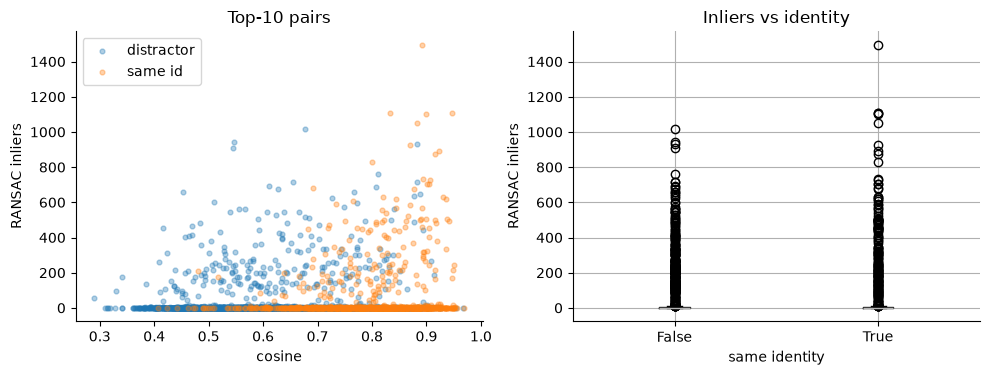

           cosine  n_inliers   n_matches
same_id                                 
False    0.598074  31.616093  314.410567
True     0.792246  52.538462  367.105161


In [8]:
sc = pd.DataFrame(scatter)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for same, group in sc.groupby("same_id"):
    axes[0].scatter(
        group["cosine"],
        group["n_inliers"],
        s=12,
        alpha=0.35,
        label="same id" if same else "distractor",
    )
axes[0].set_xlabel("cosine")
axes[0].set_ylabel("RANSAC inliers")
axes[0].set_title("Top-10 pairs")
axes[0].legend()
sc.boxplot(column="n_inliers", by="same_id", ax=axes[1])
axes[1].set_xlabel("same identity")
axes[1].set_ylabel("RANSAC inliers")
axes[1].set_title("Inliers vs identity")
plt.suptitle("")
plt.tight_layout()
fig.savefig(FIG_DIR / "verifier.png", dpi=120, bbox_inches="tight")
plt.show()
display(sc.groupby("same_id")[["cosine", "n_inliers", "n_matches"]].mean())

Saved figure (also written to `notebooks/eva02/matching_figs/verifier.png`):

![verifier](matching_figs/verifier.png)


## How to read this

- **Lines** are EfficientLoFTR correspondences on the two crops (resized internally to 640×480, keypoints mapped back).
- **`n_matches`** can fire on similar paint / wheels of a lookalike. **`n_inliers`** asks whether those points are one planar warp; that is the stricter verifier.
- Rerank never looks below cosine rank 10. A miss whose true positive is already outside the shortlist cannot be rescued.
- Fold-0 cosine Rank-1 is **0.848**. Replacing it with RANSAC inlier count drops Rank-1 to **0.437** (rescues 7 of 47 misses, breaks 134 of 262 hits). Same-id pairs have more inliers on average (53 vs 32), but the clouds overlap.
- This is OOF analysis, not a serve preset. `current_best_tuned` is unchanged.
